In [3]:
#PARTIE 01 COMPRÉHENSION 

In [ ]:
#PARTIE 02 ANALYSE EXPLORARATOIRE DES DONNEES ( EDA )

In [125]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [126]:
diabetes = pd.read_csv('diabetes.csv')  #vérification du chargement

In [127]:
diabetes.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [128]:
diabetes.shape  # ON affiche le nombre les des lignes et des colonnes 

(768, 9)

In [129]:
#4.2.1 ANALYSE STATISTIQUE DESCRIPTIVES

In [130]:
diabetes.describe()      #statistique des bases pour chaque colonne

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [131]:
# 4.2.2 VISUALISATIONS RECOMMANDÉES 

In [132]:
print(diabetes.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


In [133]:
print( "Valeurs manquantes initiales:")
print(diabetes.isnull().sum())

Valeurs manquantes initiales:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [134]:
# Hstogramme des variables numériques 

<Axes: >

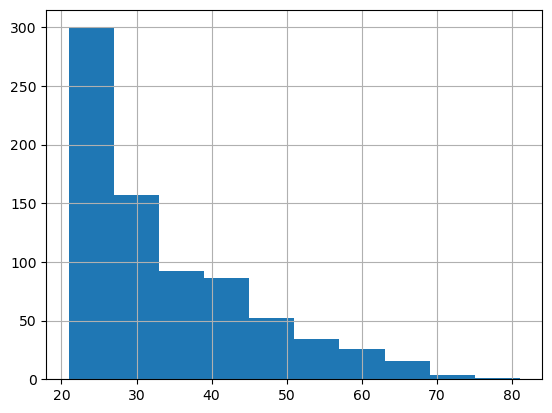

In [135]:
diabetes['Age'].hist()     #histogramme des âges 

In [136]:
#MATRICE DE CORRÉLATION 

In [137]:
np.corrcoef(diabetes) 

array([[1.        , 0.96514498, 0.96094712, ..., 0.62393696, 0.97148915,
        0.95962108],
       [0.96514498, 1.        , 0.88417913, ..., 0.59815766, 0.92389601,
        0.99415158],
       [0.96094712, 0.88417913, 1.        , ..., 0.66363579, 0.97232589,
        0.89178719],
       ...,
       [0.62393696, 0.59815766, 0.66363579, ..., 1.        , 0.63689236,
        0.61052341],
       [0.97148915, 0.92389601, 0.97232589, ..., 0.63689236, 1.        ,
        0.91318141],
       [0.95962108, 0.99415158, 0.89178719, ..., 0.61052341, 0.91318141,
        1.        ]])

In [138]:
#  HEATMAP DES CORRÉLATIONS 

<Axes: >

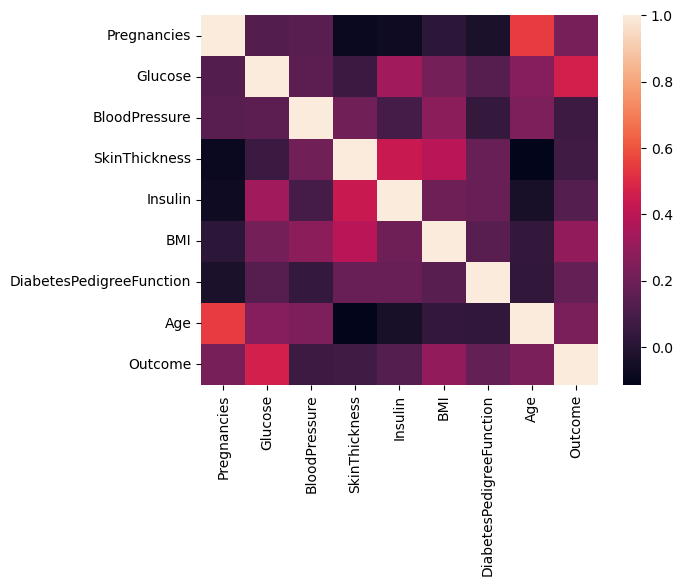

In [139]:
sns.heatmap(diabetes.corr())

In [140]:
#répartition de la variable cible

In [141]:
diabetes = diabetes.drop(['Pregnancies', 'BloodPressure', 'SkinThickness', 'Insulin'], axis =1)

In [142]:
diabetes.head()

,Glucose,BMI,DiabetesPedigreeFunction,Age,Outcome
0,148,33.6,0.627,50,1
1,85,26.6,0.351,31,0
2,183,23.3,0.672,32,1
3,89,28.1,0.167,21,0
4,137,43.1,2.288,33,1


In [143]:
#4.2.3 QUALITÉ DE DONNÉES 

In [144]:
#4.3   PRETRAITEMENT DES DONNÉES 

In [145]:
print( "Valeurs manquantes initiales:")
print(diabetes.isnull().sum())

Valeurs manquantes initiales:
Glucose                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [146]:
# NETOYAGE DU DATASET

In [147]:
diabetes = diabetes.drop_duplicates()
print("Dimensions après suppression des oublons :", diabetes.shape)

Dimensions après suppression des oublons : (768, 5)


In [148]:
# TRAITEment DES   VALEURS MANQUANTES 

In [149]:
colonne_avec_zero_comme_valmanquante= ["Glucose","BMI","DiabetesPedigreeFunction"]
diabetes[colonne_avec_zero_comme_valmanquante] = diabetes[colonne_avec_zero_comme_valmanquante].replace(0, np.nan)

print("\nValeurs manquantes après remplacement des 0 par NaN : ")
print(diabetes.isnull().sum())


Valeurs manquantes après remplacement des 0 par NaN : 
Glucose                      5
BMI                         11
DiabetesPedigreeFunction     0
Age                          0
Outcome                      0
dtype: int64


In [150]:
diabetes.shape

(768, 5)

In [151]:
# SEPARATION FEATURES / TARGET

In [152]:
x = diabetes.drop("Outcome", axis = 1)
y = diabetes["Outcome"]

print("variables d'entrée (x) :")
print(x.columns.tolist())

print("variables de sortie (y) :")
print("Outcome")


variables d'entrée (x) :
['Glucose', 'BMI', 'DiabetesPedigreeFunction', 'Age']
variables de sortie (y) :
Outcome


In [153]:
# ENCODAGE DES VARIABLES CATEGORIELLES

In [160]:
from sklearn.preprocessing import OrdinalEncoder

In [161]:
encoder = OrdinalEncoder()
encoder.fit_transform(x)

array([[ 85., 122., 350.,  29.],
       [ 22.,  61., 196.,  10.],
       [120.,  29., 368.,  11.],
       ...,
       [ 58.,  57., 115.,   9.],
       [ 63.,  94., 195.,  26.],
       [ 30.,  97., 169.,   2.]])

In [165]:
from sklearn.preprocessing import OneHotEncoder

In [166]:
encoder = OneHotEncoder()
encoder.fit_transform(x)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 3072 stored elements and shape (768, 953)>

In [162]:
transformer = LabelEncoder()
transformer.fit(y)          # sur une ligne

LabelEncoder()

In [167]:
#NORMALISATION

In [168]:
from sklearn.preprocessing import MinMaxScaler

In [172]:
scaler= MinMaxScaler()
scaler.fit_transform(x)

array([[0.67096774, 0.31492843, 0.23441503, 0.48333333],
       [0.26451613, 0.17177914, 0.11656704, 0.16666667],
       [0.89677419, 0.10429448, 0.25362938, 0.18333333],
       ...,
       [0.49677419, 0.16359918, 0.07130658, 0.15      ],
       [0.52903226, 0.24335378, 0.11571307, 0.43333333],
       [0.31612903, 0.24948875, 0.10119556, 0.03333333]])

In [175]:
#       standarisation 

In [176]:
from sklearn.preprocessing import StandardScaler

In [177]:
scaler= StandardScaler()
scaler.fit_transform(x)

array([[ 0.86228736,  0.16509656,  0.46849198,  1.4259954 ],
       [-1.20222881, -0.84640379, -0.36506078, -0.19067191],
       [ 2.0092408 , -1.32325395,  0.60439732, -0.10558415],
       ...,
       [-0.02250528, -0.90420381, -0.68519336, -0.27575966],
       [ 0.14134521, -0.34065362, -0.37110101,  1.17073215],
       [-0.94006803, -0.2973036 , -0.47378505, -0.87137393]])

array([[ 0.73809524,  0.14285714,  0.66535948,  1.23529412],
       [-0.76190476, -0.62637363, -0.05620915,  0.11764706],
       [ 1.57142857, -0.98901099,  0.78300654,  0.17647059],
       ...,
       [ 0.0952381 , -0.67032967, -0.33333333,  0.05882353],
       [ 0.21428571, -0.24175824, -0.06143791,  1.05882353],
       [-0.57142857, -0.20879121, -0.1503268 , -0.35294118]])

In [286]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer


In [288]:
numeric_features = x.columns.tolist()
numeric_transformer = Pipeline(
                                steps=[("imputer", SimpleImputer(strategy = "median")),
                                       ("scaler", StandardScaler())])

processor = ColumnTransformer(transformers=[("num", numeric_transformer, numeric_features)])

In [291]:
imputer=SimpleImputer(strategy = "median")

In [292]:
#SEPARATION DES DONNÉES 

In [293]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state = 5)     #diviser les données en des tableaux  avec 20% des données dans le test

In [294]:
x_train= imputer.fit_transform(x_train)
x_test= imputer.transform(x_test)

In [295]:
# 4.4 PARTIE 4 : MODÉLISATION 

In [296]:
#   a) DESCISION TREE


In [333]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import time

In [298]:
#model simple

In [334]:
dt_model = DecisionTreeClassifier(random_state = 42)
start = time.time()
dt_model.fit(x_train, y_train)

DecisionTreeClassifier(random_state=42)

In [335]:
# Prédiction

In [339]:
start = time.time()
dt_model.fit(x_train, y_train)
y_pred_train = dt_model.predict(x_train)
y_pred_test = dt_model.predict(x_test)

end = time.time()

print("Accuracy Train : ", accuracy_score(y_train, y_pred_train))

print("____________________________________________________")
print("Accuracy Test : ", accuracy_score(y_test, y_pred_test), "%")

print("____________________________________________________")

print("temps total : " , end - start, "secondes")

Accuracy Train :  1.0
____________________________________________________
Accuracy Test :  0.7272727272727273 %
____________________________________________________
temps total :  0.014618396759033203 secondes


In [340]:
#  VISUALISATION DE L 'ARBRE

In [341]:
from sklearn.tree import plot_tree

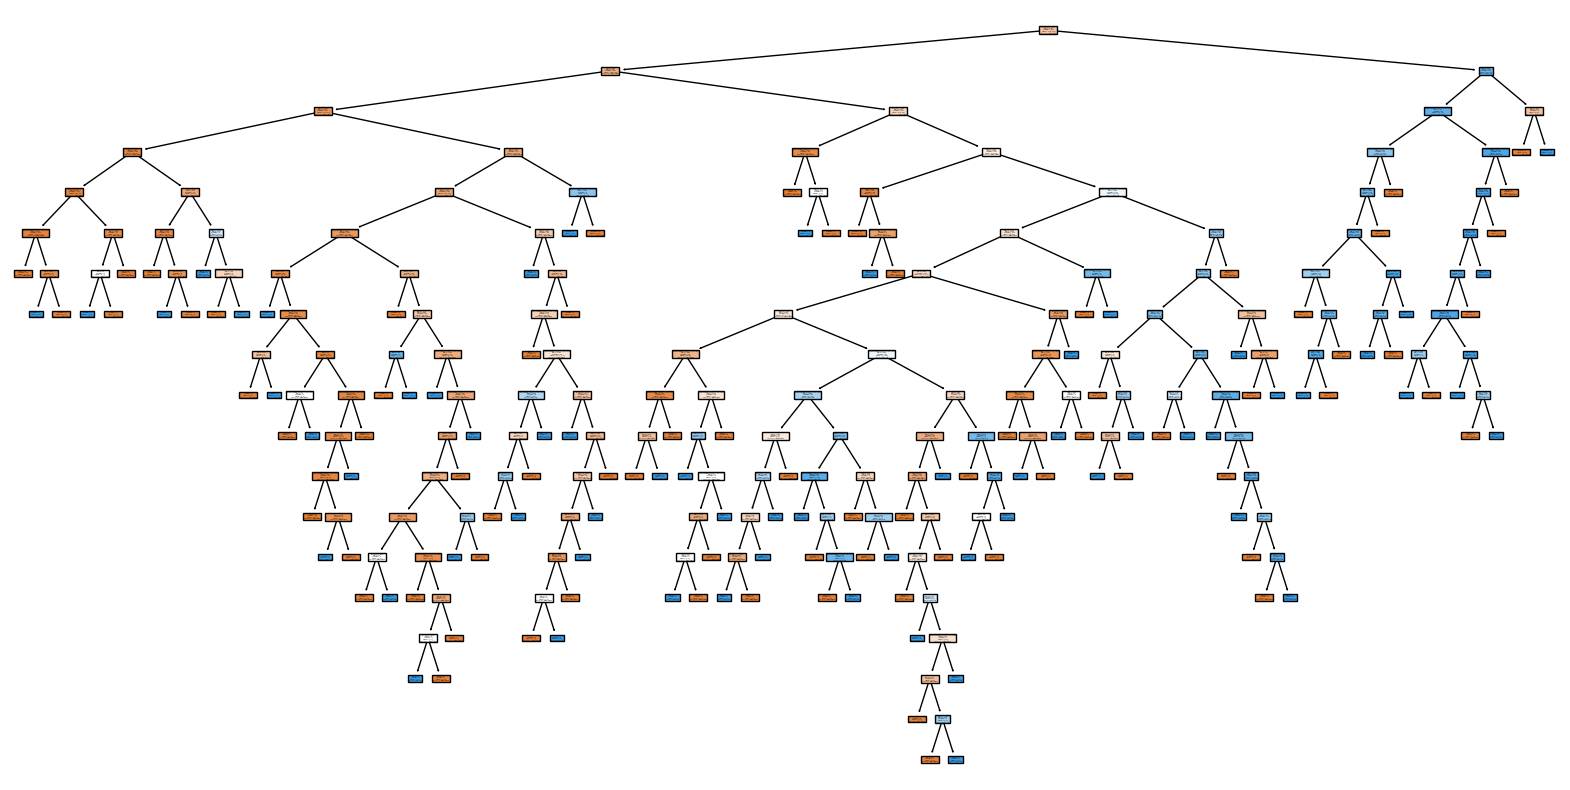

In [342]:
plt.figure(figsize=(20, 10))
plot_tree(dt_model, feature_names = x.columns, class_names= ["Non Diabtetique", "Diabetique"],
          filled = True)
plt.show()

In [343]:
# Etudier l'effet de la profondeur

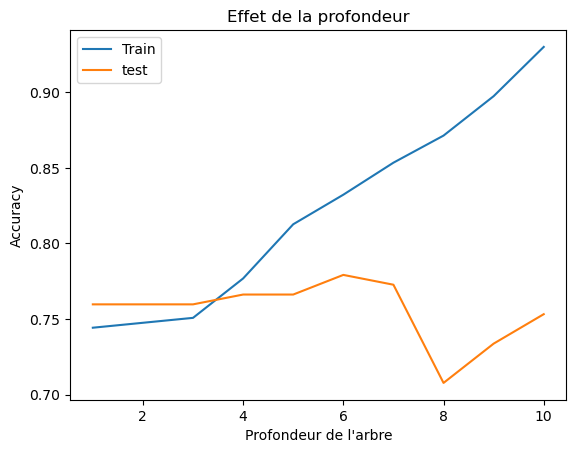

In [353]:
depths = range(1, 11)


train_scores = []
test_scores =[]

for d in depths:
    model = DecisionTreeClassifier(max_depth =d, random_state = 42)
    model.fit(x_train, y_train)

    train_scores.append(model.score(x_train , y_train))

    test_scores.append(model.score(x_test, y_test))


plt.plot(depths, train_scores,label = "Train")
plt.plot(depths, test_scores, label="test")
plt.xlabel("Profondeur de l'arbre")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Effet de la profondeur")
plt.show()



Overfitting (Point Clé)

A partir de profondeur > 6:

                        Train continue à monter
                        Test chute

Interprétation :

        L 'Arbre devient:
        trop complexe
        memorise les données
        perd sa capacité à généraliser

In [354]:
from sklearn.metrics import classification_report


In [355]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.80      0.78      0.79       100
           1       0.61      0.63      0.62        54

    accuracy                           0.73       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.73      0.73      0.73       154



In [356]:
#b) Random forest 


In [357]:
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score

In [359]:
start = time.time()
rf_model = RandomForestClassifier(random_state= 42)

rf_model.fit(x_train, y_train)

y_pred_rf = rf_model.predict(x_test)
end = time.time()
print("Accuray Random Forest : ", accuracy_score(y_test, y_pred_rf),"%")
print("temps total : " , end - start, "secondes")

Accuray Random Forest :  0.7792207792207793 %
temps total :  0.5433199405670166 secondes


In [360]:
# Test des plusieurs valeurs de n_estimators = nombre d'abre

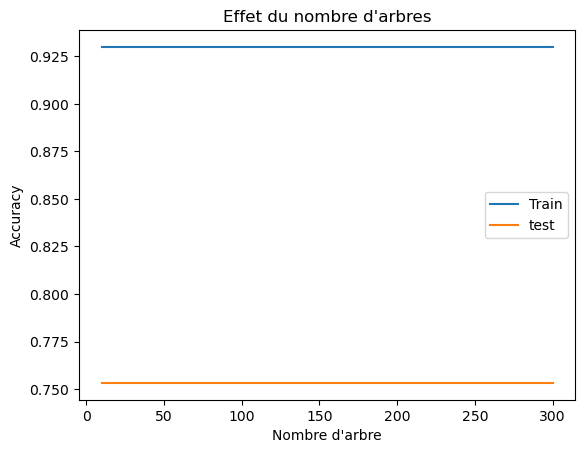

In [361]:
n_values = [10, 50, 100, 200, 300]

train_scores = []
test_scores = []

for n in n_values:
    mpdel = RandomForestClassifier(n_estimators =n, random_state = 42)
    model.fit(x_train, y_train)

    train_scores.append(model.score(x_train, y_train))
    test_scores.append(model.score(x_test,y_test))


plt.plot(n_values, train_scores,label = "Train")
plt.plot(n_values, test_scores, label="test")
plt.xlabel("Nombre d'arbre")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Effet du nombre d'arbres")
plt.show()

MOdele                 Train             Test         overfitting
 
Décision  Tree      très élevé        moyenne             élevé

Random Forest       élevé             élevé              faible

Analyse

ranom Forest = Model Robuste et Stable

Variables imprtantes

Glucose

BMI

Age

DiabetesPedigreeFunction

In [362]:
#4.2.2 KNN

In [363]:
from sklearn.neighbors import KNeighborsClassifier 

In [364]:
# K  = Nombre de voisin

In [371]:
knn = KNeighborsClassifier(n_neighbors = 5 )
start = time.time()
knn.fit(x_train, y_train)
y_pred = knn.predict(x_test)

end = time.time()

score= accuracy_score(y_test, y_pred)

print("score KNN :" , score ,"%")

print("_____________________________________________")
print("Temps KNN : ", end - start ,"secondes")

score KNN : 0.7922077922077922 %
_____________________________________________
Temps KNN :  0.06268143653869629 secondes


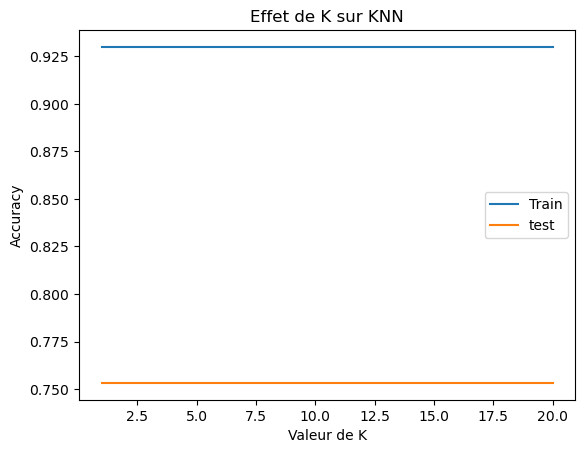

In [365]:
k_valeurs = range(1, 21)

train_scores = []
test_scores = []

for k in k_valeurs:
    mpdel = KNeighborsClassifier(n_neighbors = k, )
    model.fit(x_train, y_train)

    train_scores.append(model.score(x_train, y_train))
    test_scores.append(model.score(x_test,y_test))


plt.plot(k_valeurs, train_scores,label = "Train")
plt.plot(k_valeurs, test_scores, label="test")
plt.xlabel("Valeur de K")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Effet de K sur KNN")
plt.show()

In [318]:
# Avec la normalisation

In [319]:
from sklearn.preprocessing import StandardScaler

In [370]:
start = time.time()
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

end = time.time()
model.fit(x_train_scaled, y_train)
print("temps total : " , end - start, "secondes")


temps total :  0.004888296127319336 secondes


In [321]:
 #SVMlinéaire

In [322]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
from sklearn.preprocessing import StandardScaler

In [323]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

svm_linear = SVC(kernel='linear', C=1.0, random_state=42)

svm_linear.fit(x_train_scaled, y_train)

SVC(kernel='linear', random_state=42)

In [368]:
start = time.time()
svm_linear.fit(x_train_scaled, y_train)
y_pred_linear = svm_linear.predict(x_test_scaled)
end = time.time()
print("=== SVM Linéaire ===")
print("Accuracy :", accuracy_score(y_test, y_pred_linear))
print("Matrice de confusion :")
print(confusion_matrix(y_test, y_pred_linear))
print("Rapport de classification :")
print(classification_report(y_test, y_pred_linear))
print("temps total : " , end - start, "secondes")

=== SVM Linéaire ===
Accuracy : 0.8051948051948052
Matrice de confusion :
[[90 10]
 [20 34]]
Rapport de classification :
              precision    recall  f1-score   support

           0       0.82      0.90      0.86       100
           1       0.77      0.63      0.69        54

    accuracy                           0.81       154
   macro avg       0.80      0.76      0.78       154
weighted avg       0.80      0.81      0.80       154

temps total :  0.03179454803466797 secondes


In [ ]:
# SVMRBF

In [330]:
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_rbf.fit(x_train_scaled, y_train)

SVC(random_state=42)

In [367]:
start = time.time()
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_rbf.fit(x_train_scaled, y_train)
y_pred_rbf = svm_rbf.predict(x_test_scaled)
end = time.time()
print("=== SVM RBF ===")
print("Accuracy :", accuracy_score(y_test, y_pred_rbf))
print("Matrice de confusion :")
print(confusion_matrix(y_test, y_pred_rbf))
print("Rapport de classification :")
print(classification_report(y_test, y_pred_rbf))
print("temps total : " , end - start, "secondes")

=== SVM RBF ===
Accuracy : 0.7857142857142857
Matrice de confusion :
[[90 10]
 [23 31]]
Rapport de classification :
              precision    recall  f1-score   support

           0       0.80      0.90      0.85       100
           1       0.76      0.57      0.65        54

    accuracy                           0.79       154
   macro avg       0.78      0.74      0.75       154
weighted avg       0.78      0.79      0.78       154

temps total :  0.053009033203125 secondes


In [ ]:
# Comparaison

In [332]:
results_svm = pd.DataFrame({
"Modèle": ["SVM linéaire", "SVM RBF"],
"Accuracy": [
accuracy_score(y_test, y_pred_linear),
accuracy_score(y_test, y_pred_rbf)
]
})
print("=== Comparaison ===")
print(results_svm)

=== Comparaison ===
         Modèle  Accuracy
0  SVM linéaire  0.805195
1       SVM RBF  0.785714
